In [ ]:
from pathlib import Path
import time
import csv
import numpy as np
import cv2
import tensorflow as tf
import keras
import keras_cv
import onnxruntime as ort
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================
PROJECT_ROOT = Path("/workspace")

MODELS_DIR = PROJECT_ROOT / "models"
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = MODELS_DIR / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DETECTOR_MODEL_PATH = MODELS_DIR / "dice_detector_best_20260330_114353.keras"
TF_CLASSIFIER_MODEL_PATH = MODELS_DIR / "dice_classifier_best.keras"
ONNX_CLASSIFIER_MODEL_PATH = MODELS_DIR / "onnx" / "dice_classifier.onnx"
IMAGE_DIR = DATA_DIR / "raw" / "images"

BOUNDING_BOX_FORMAT = "xyxy"
DETECTOR_TARGET_SIZE = 640
CLASSIFIER_IMG_SIZE = (384, 384)
DETECTOR_CONFIDENCE_THRESHOLD = 0.45
DETECTOR_IOU_THRESHOLD = 0.5
CROP_MARGIN = 0.12
N_IMAGES = 20
N_WARMUP = 3

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODELS_DIR:", MODELS_DIR)
print("DATA_DIR:", DATA_DIR)
print("IMAGE_DIR:", IMAGE_DIR)
print("DETECTOR_MODEL_PATH:", DETECTOR_MODEL_PATH)
print("TF_CLASSIFIER_MODEL_PATH:", TF_CLASSIFIER_MODEL_PATH)
print("ONNX_CLASSIFIER_MODEL_PATH:", ONNX_CLASSIFIER_MODEL_PATH)

assert DETECTOR_MODEL_PATH.exists(), f"Missing detector model: {DETECTOR_MODEL_PATH}"
assert TF_CLASSIFIER_MODEL_PATH.exists(), f"Missing TF classifier model: {TF_CLASSIFIER_MODEL_PATH}"
assert ONNX_CLASSIFIER_MODEL_PATH.exists(), f"Missing ONNX classifier model: {ONNX_CLASSIFIER_MODEL_PATH}"
assert IMAGE_DIR.exists(), f"Missing image directory: {IMAGE_DIR}"

# =========================================================
# LOAD MODELS
# =========================================================
detector = keras.models.load_model(DETECTOR_MODEL_PATH, compile=False)
detector.prediction_decoder = keras_cv.layers.NonMaxSuppression(
    bounding_box_format=BOUNDING_BOX_FORMAT,
    from_logits=False,
    confidence_threshold=DETECTOR_CONFIDENCE_THRESHOLD,
    iou_threshold=DETECTOR_IOU_THRESHOLD,
)

tf_classifier = keras.models.load_model(TF_CLASSIFIER_MODEL_PATH, compile=False)

ort_session = ort.InferenceSession(
    str(ONNX_CLASSIFIER_MODEL_PATH),
    providers=["CPUExecutionProvider"],
)
onnx_input_name = ort_session.get_inputs()[0].name
onnx_output_name = ort_session.get_outputs()[0].name

# Warm build
_ = detector.predict(
    np.zeros((1, DETECTOR_TARGET_SIZE, DETECTOR_TARGET_SIZE, 3), dtype=np.float32),
    verbose=0
)
_ = tf_classifier(
    tf.zeros((1, CLASSIFIER_IMG_SIZE[0], CLASSIFIER_IMG_SIZE[1], 3), dtype=tf.float32),
    training=False
)
_ = ort_session.run(
    [onnx_output_name],
    {onnx_input_name: np.zeros((1, CLASSIFIER_IMG_SIZE[0], CLASSIFIER_IMG_SIZE[1], 3), dtype=np.float32)}
)

print("ONNX classifier input:", onnx_input_name)
print("ONNX classifier output:", onnx_output_name)

# =========================================================
# HELPERS
# =========================================================
def list_images(folder: Path):
    exts = {".jpg", ".jpeg", ".png"}
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in exts])

def load_image_bgr(image_path: Path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise FileNotFoundError(image_path)
    return image

def bgr_to_rgb(image_bgr: np.ndarray):
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

def preprocess_for_detector(image_rgb: np.ndarray):
    orig_h, orig_w = image_rgb.shape[:2]
    scale = min(DETECTOR_TARGET_SIZE / orig_w, DETECTOR_TARGET_SIZE / orig_h)
    new_w = int(round(orig_w * scale))
    new_h = int(round(orig_h * scale))

    resized = cv2.resize(image_rgb, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.zeros((DETECTOR_TARGET_SIZE, DETECTOR_TARGET_SIZE, 3), dtype=np.uint8)

    pad_left = (DETECTOR_TARGET_SIZE - new_w) // 2
    pad_top = (DETECTOR_TARGET_SIZE - new_h) // 2
    canvas[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = resized

    image_resized = tf.convert_to_tensor(canvas, dtype=tf.float32) / 255.0
    return image_resized, float(scale), float(pad_left), float(pad_top), orig_h, orig_w

def map_box_to_original(box_xyxy, scale, pad_left, pad_top, orig_h, orig_w):
    x1, y1, x2, y2 = map(float, box_xyxy)
    x1 = (x1 - pad_left) / scale
    y1 = (y1 - pad_top) / scale
    x2 = (x2 - pad_left) / scale
    y2 = (y2 - pad_top) / scale

    x1 = max(0.0, min(orig_w, x1))
    y1 = max(0.0, min(orig_h, y1))
    x2 = max(0.0, min(orig_w, x2))
    y2 = max(0.0, min(orig_h, y2))
    return np.array([x1, y1, x2, y2], dtype=np.float32)

def expand_box(box_xyxy, image_shape, margin=CROP_MARGIN):
    h, w = image_shape[:2]
    x1, y1, x2, y2 = map(float, box_xyxy)
    bw = x2 - x1
    bh = y2 - y1

    x1 -= bw * margin
    y1 -= bh * margin
    x2 += bw * margin
    y2 += bh * margin

    x1 = int(max(0, round(x1)))
    y1 = int(max(0, round(y1)))
    x2 = int(min(w, round(x2)))
    y2 = int(min(h, round(y2)))

    if x2 <= x1 or y2 <= y1:
        return None
    return np.array([x1, y1, x2, y2], dtype=np.int32)

def crop_from_box(image_rgb, box_xyxy):
    x1, y1, x2, y2 = map(int, box_xyxy)
    crop = image_rgb[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    return crop

def preprocess_crop_for_classifier(crop_rgb):
    crop_resized = cv2.resize(crop_rgb, CLASSIFIER_IMG_SIZE, interpolation=cv2.INTER_LINEAR)
    crop_resized = crop_resized.astype(np.float32)
    crop_resized = keras.applications.efficientnet.preprocess_input(crop_resized)
    return crop_resized

def classify_crops_tf(crops_rgb):
    if len(crops_rgb) == 0:
        return 0

    for crop_rgb in crops_rgb:
        crop_input = preprocess_crop_for_classifier(crop_rgb)[None, ...].astype(np.float32)
        _ = tf_classifier(crop_input, training=False)

    return len(crops_rgb)

def classify_crops_onnx(crops_rgb):
    if len(crops_rgb) == 0:
        return 0

    for crop_rgb in crops_rgb:
        crop_input = preprocess_crop_for_classifier(crop_rgb)[None, ...].astype(np.float32)
        _ = ort_session.run([onnx_output_name], {onnx_input_name: crop_input})[0]

    return len(crops_rgb)

def run_pipeline_on_image(image_path: Path):
    t0 = time.perf_counter()

    image_bgr = load_image_bgr(image_path)
    image_rgb = bgr_to_rgb(image_bgr)

    t1 = time.perf_counter()

    image_resized, scale, pad_left, pad_top, orig_h, orig_w = preprocess_for_detector(image_rgb)

    t2 = time.perf_counter()

    preds = detector.predict(image_resized[None, ...], verbose=0)

    if isinstance(preds, dict):
        preds = {k: np.asarray(v) for k, v in preds.items()}
    else:
        raise TypeError(f"Unexpected detector output type: {type(preds)}")

    num_det = int(preds["num_detections"][0]) if "num_detections" in preds else len(preds["boxes"][0])
    pred_boxes = np.asarray(preds["boxes"][0][:num_det], dtype=np.float32).reshape(-1, 4)

    if "confidence" in preds:
        pred_scores = np.asarray(preds["confidence"][0][:num_det], dtype=np.float32).reshape(-1)
    elif "scores" in preds:
        pred_scores = np.asarray(preds["scores"][0][:num_det], dtype=np.float32).reshape(-1)
    else:
        raise KeyError(f"Detector output missing confidence/scores. Keys: {list(preds.keys())}")

    kept_crops = []
    for box_resized, det_score in zip(pred_boxes, pred_scores):
        if det_score < DETECTOR_CONFIDENCE_THRESHOLD:
            continue

        box_orig = map_box_to_original(box_resized, scale, pad_left, pad_top, orig_h, orig_w)
        box_crop = expand_box(box_orig, image_rgb.shape, margin=CROP_MARGIN)
        if box_crop is None:
            continue

        crop_rgb = crop_from_box(image_rgb, box_crop)
        if crop_rgb is None:
            continue

        kept_crops.append(crop_rgb)

    t3 = time.perf_counter()

    n_tf = classify_crops_tf(kept_crops)

    t4 = time.perf_counter()

    n_onnx = classify_crops_onnx(kept_crops)

    t5 = time.perf_counter()

    return {
        "image": image_path.name,
        "io_ms": (t1 - t0) * 1000.0,
        "preproc_ms": (t2 - t1) * 1000.0,
        "detect_ms": (t3 - t2) * 1000.0,
        "crop_classify_tf_ms": (t4 - t3) * 1000.0,
        "crop_classify_onnx_ms": (t5 - t4) * 1000.0,
        "total_tf_ms": (t4 - t0) * 1000.0,
        "total_onnx_ms": ((t1 - t0) + (t2 - t1) + (t3 - t2) + (t5 - t4)) * 1000.0,
        "detections": len(kept_crops),
        "classified_crops_tf": n_tf,
        "classified_crops_onnx": n_onnx,
    }

# =========================================================
# IMAGE LIST
# =========================================================
image_paths = list_images(IMAGE_DIR)[:N_IMAGES]
assert len(image_paths) > 0, "No input images found"
print(f"Found {len(image_paths)} images for benchmark.")

# =========================================================
# WARM-UP
# =========================================================
warmup_images = image_paths[:min(N_WARMUP, len(image_paths))]
for image_path in warmup_images:
    _ = run_pipeline_on_image(image_path)

print(f"Warm-up finished on {len(warmup_images)} images.")

# =========================================================
# BENCHMARK
# =========================================================
rows = []
failed = []

for image_path in image_paths:
    try:
        rows.append(run_pipeline_on_image(image_path))
    except Exception as e:
        failed.append((image_path.name, str(e)))

assert len(rows) > 0, "Benchmark failed on all images."

if failed:
    print("\nFailed images:")
    for name, err in failed:
        print(f" - {name}: {err}")

# =========================================================
# CSV EXPORT
# =========================================================
csv_path = REPORTS_DIR / "latency_pipeline_classifier_tf_vs_onnx.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)

print("Saved CSV:", csv_path)

# =========================================================
# SUMMARY
# =========================================================
shared_keys = ["io_ms", "preproc_ms", "detect_ms"]
tf_keys = ["crop_classify_tf_ms", "total_tf_ms"]
onnx_keys = ["crop_classify_onnx_ms", "total_onnx_ms"]

means = {k: float(np.mean([r[k] for r in rows])) for k in shared_keys + tf_keys + onnx_keys}
medians = {k: float(np.median([r[k] for r in rows])) for k in shared_keys + tf_keys + onnx_keys}
mins = {k: float(np.min([r[k] for r in rows])) for k in shared_keys + tf_keys + onnx_keys}
maxs = {k: float(np.max([r[k] for r in rows])) for k in shared_keys + tf_keys + onnx_keys}
stds = {k: float(np.std([r[k] for r in rows])) for k in shared_keys + tf_keys + onnx_keys}

print("\nSUMMARY")
for k in shared_keys + tf_keys + onnx_keys:
    print(
        f"{k}: mean={means[k]:.2f} ms | "
        f"median={medians[k]:.2f} ms | "
        f"std={stds[k]:.2f} ms | "
        f"min={mins[k]:.2f} ms | "
        f"max={maxs[k]:.2f} ms"
    )

print("Average detections per image:", float(np.mean([r["detections"] for r in rows])))
print("Average classified crops TF:", float(np.mean([r["classified_crops_tf"] for r in rows])))
print("Average classified crops ONNX:", float(np.mean([r["classified_crops_onnx"] for r in rows])))
print("Failed images:", len(failed))

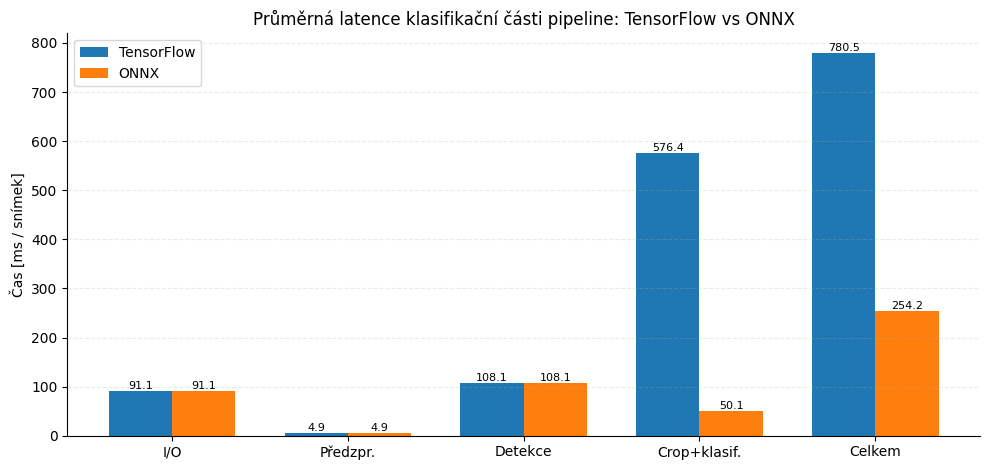

Saved plot: /workspace/models/reports/latency_pipeline_classifier_tf_vs_onnx_mean.png


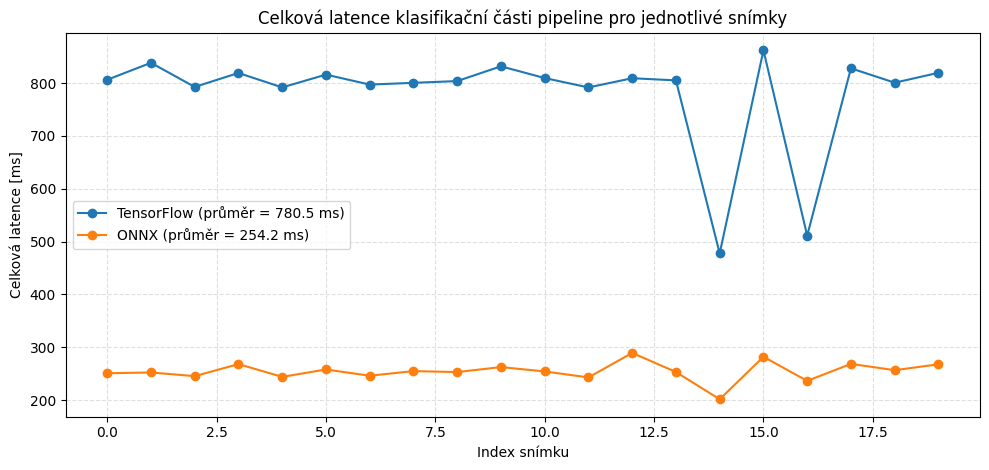

Saved plot: /workspace/models/reports/latency_pipeline_classifier_tf_vs_onnx_total_per_image.png


In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

assert "rows" in globals(), "Run the benchmark cell first."
assert len(rows) > 0, "No benchmark rows available."

REPORTS_DIR = Path("/workspace/models/reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================
# PLOT 1: mean latency, TF vs ONNX
# =========================================================
labels = ["I/O", "Předzpr.", "Detekce", "Crop+klasif.", "Celkem"]

tf_values = [
    means["io_ms"],
    means["preproc_ms"],
    means["detect_ms"],
    means["crop_classify_tf_ms"],
    means["total_tf_ms"],
]

onnx_values = [
    means["io_ms"],
    means["preproc_ms"],
    means["detect_ms"],
    means["crop_classify_onnx_ms"],
    means["total_onnx_ms"],
]

x = np.arange(len(labels))
width = 0.36

plt.figure(figsize=(10, 4.8))
bars_tf = plt.bar(x - width / 2, tf_values, width, label="TensorFlow")
bars_onnx = plt.bar(x + width / 2, onnx_values, width, label="ONNX")

plt.xticks(x, labels)
plt.ylabel("Čas [ms / snímek]")
plt.title("Průměrná latence klasifikační části pipeline: TensorFlow vs ONNX")
plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.legend()

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bars in (bars_tf, bars_onnx):
    for b in bars:
        v = b.get_height()
        plt.text(
            b.get_x() + b.get_width() / 2,
            v,
            f"{v:.1f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

plot_mean_path = REPORTS_DIR / "latency_pipeline_classifier_tf_vs_onnx_mean.png"
plt.savefig(plot_mean_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_mean_path)

# =========================================================
# PLOT 2: total latency per image, TF vs ONNX
# =========================================================
tf_total_values = [r["total_tf_ms"] for r in rows]
onnx_total_values = [r["total_onnx_ms"] for r in rows]

plt.figure(figsize=(10, 4.8))
plt.plot(
    range(len(tf_total_values)),
    tf_total_values,
    marker="o",
    label=f"TensorFlow (průměr = {means['total_tf_ms']:.1f} ms)"
)
plt.plot(
    range(len(onnx_total_values)),
    onnx_total_values,
    marker="o",
    label=f"ONNX (průměr = {means['total_onnx_ms']:.1f} ms)"
)

plt.xlabel("Index snímku")
plt.ylabel("Celková latence [ms]")
plt.title("Celková latence klasifikační části pipeline pro jednotlivé snímky")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plot_total_path = REPORTS_DIR / "latency_pipeline_classifier_tf_vs_onnx_total_per_image.png"
plt.savefig(plot_total_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_total_path)